In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
honey = pd.read_csv('../../data/honey.csv')
honey.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


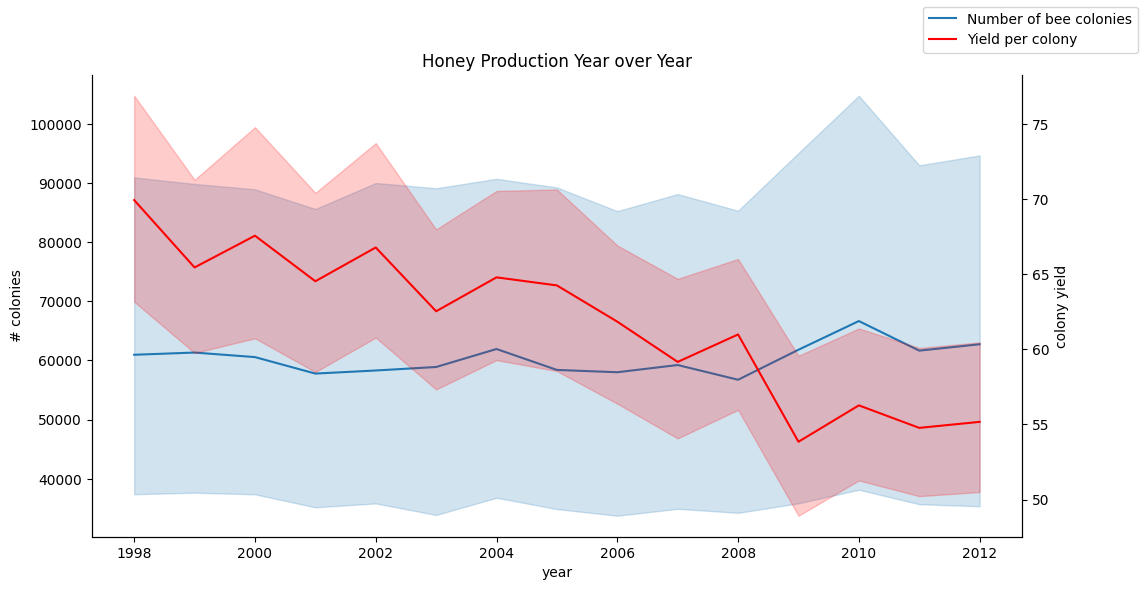

In [33]:
fig, ax = plt.subplots(figsize=(12,6))
lineplot = sns.lineplot(x=honey['year'], y=honey['numcol'], data=honey, 
                        label = 'Number of bee colonies', legend=False)
sns.despine()
plt.ylabel('# colonies')
plt.title('Honey Production Year over Year');

ax2 = ax.twinx()
lineplot2 = sns.lineplot(x=honey['year'], y=honey['yieldpercol'], ax=ax2, color="r", 
                         label ='Yield per colony', legend=False) 
sns.despine(right=False)
plt.ylabel('colony yield')
ax.figure.legend();

You can infer from this graph that there is a sight increase of the number of colonies over the years while their production yield is decreasing therefore they are less used.

In [ ]:
honey_temp = honey[
    honey['yieldpercol'] >= honey.groupby('year')['yieldpercol'].transform(lambda x: x.quantile(0.75))
]
print(honey_temp.groupby('year')['state'].count())

year
1998    11
1999    11
2000    11
2001    11
2002    11
2003    12
2004    11
2005    11
2006    11
2007    12
2008    11
2009    11
2010    10
2011    10
2012    10
Name: state, dtype: int64


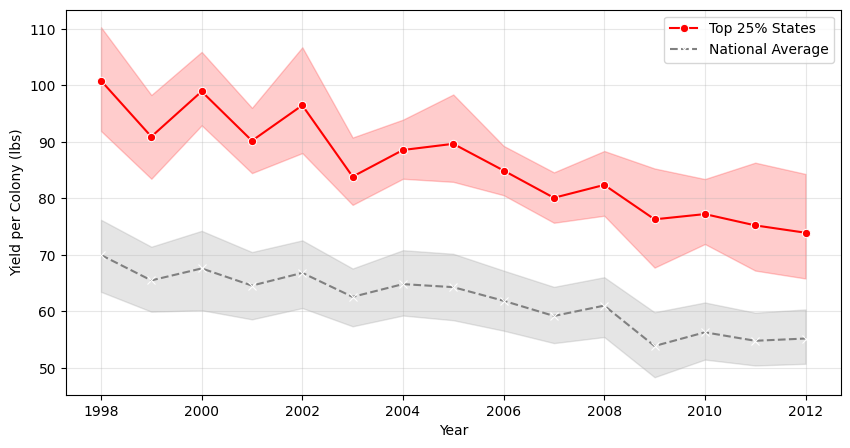

In [47]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=honey_temp, x='year', y='yieldpercol', marker='o', color='red', label='Top 25% States')

# Plot the average yield of ALL states over time for comparison
sns.lineplot(data=honey, x='year', y='yieldpercol', marker='x', color='gray', linestyle='--', label='National Average')

plt.ylabel("Yield per Colony (lbs)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.show()


You can also see the the top honey producers fell over the years more than the national average fall off.

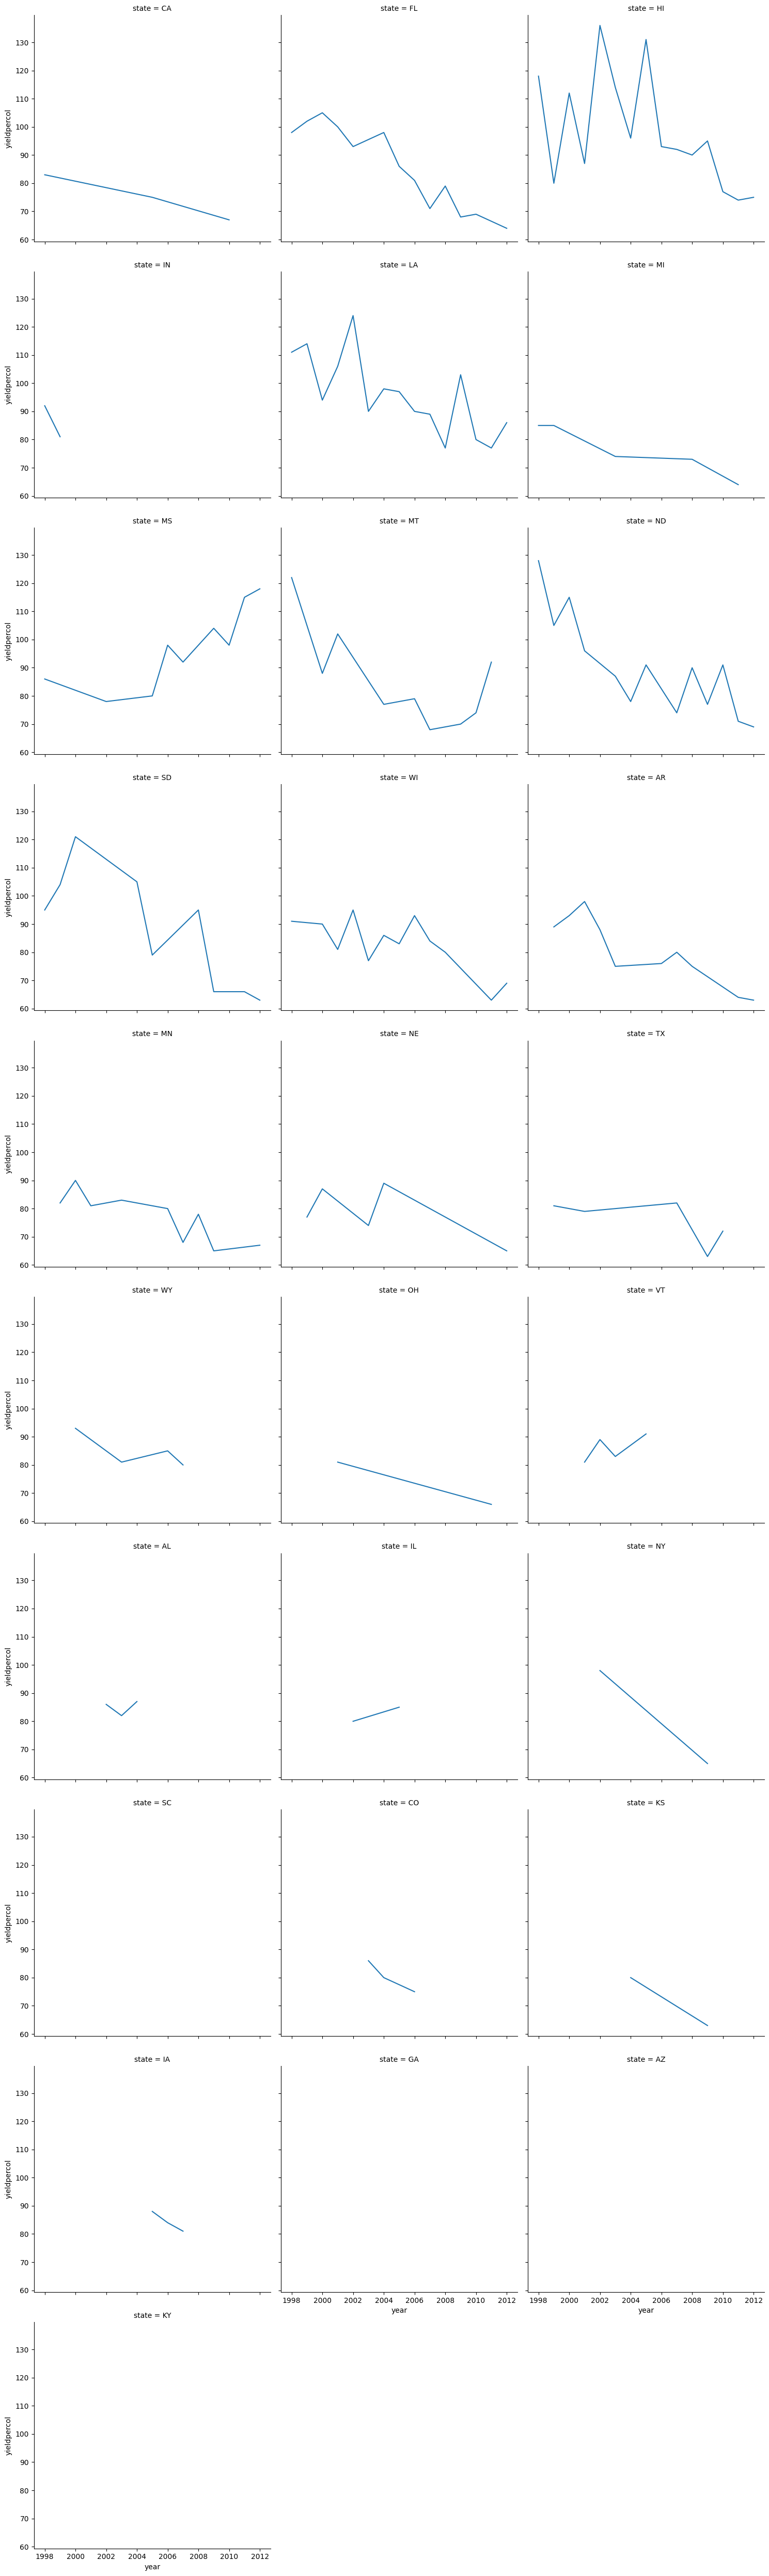

In [49]:
sns.relplot(
    data=honey_temp, 
    x="year", y="yieldpercol",
    col="state", 
    col_wrap=3,
    kind="line"
    )

From here you can see the top states of honey production, and most of them fell off during the years.